In [1]:
%load_ext autoreload
%autoreload 2

import os
# Workaround for Mac M1 OpenMP conflict when loading torch
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

#import pytorch_lightning as pl
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt

from pytorch_lightning import Trainer
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint

from footprinting import plot_count_matrix, get_count_matrix, average_counts_by_fraglen, counts_by_fraglen, get_footprint_and_procap, get_valid_windows, detect_blobs

from datasets import FootprintDataModule
from models    import UNetLightning
from functools import partial
import wandb


In [2]:
# Define test input data 
counts_gz = '../data/mesc_microC_3hrDMSO_chr8.counts.tsv.gz'
#counts_gz = '../test_data/mesc_microc_test.counts.tsv.gz'
procap_bw = '../data/GSM2170014_Pro_mESC.ucsc_mm10.bw'

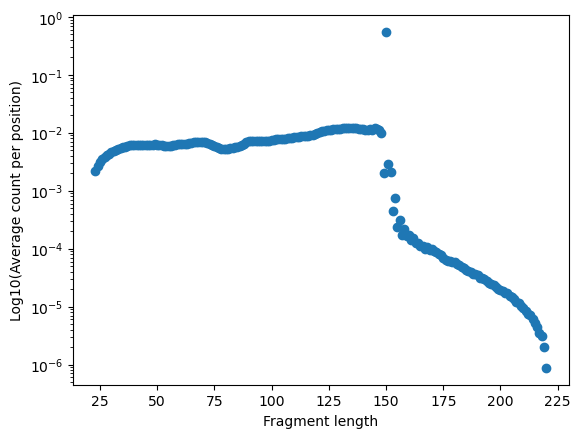

In [3]:
# Get normalization factors (i.e. average counts per fragment length)

#avg_by_len = average_counts_by_fraglen(counts_gz, chrom)

# Save avg_by_len to file
#with open('avg_by_len.pkl', 'wb') as f:
#    pickle.dump(avg_by_len, f)

# Load avg_by_len from file
with open('avg_by_len.pkl', 'rb') as f:
    avg_by_len = pickle.load(f)

# Plot log10(avg_by_len) - scatter plot
plt.scatter(avg_by_len.keys(), list(avg_by_len.values()))
plt.yscale('log')
plt.xlabel('Fragment length')
plt.ylabel('Log10(Average count per position)')
plt.show()


0.0069310742116494035


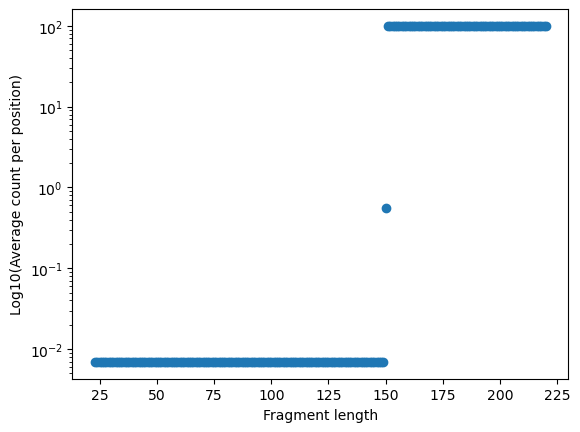

In [4]:
# Replace all avg_by_len values for length <150 by the median of the values for length <150
median = np.median([v for k, v in avg_by_len.items() if k < 150])
for k in avg_by_len:
    if k < 150:
        avg_by_len[k] = median
    if k > 150:
        avg_by_len[k] = 100        

print(median)
# Plot log10(avg_by_len) - scatter plot
plt.scatter(avg_by_len.keys(), list(avg_by_len.values()))
plt.yscale('log')
plt.xlabel('Fragment length')
plt.ylabel('Log10(Average count per position)')
plt.show()


(121, 1001) (121,) (1001,)


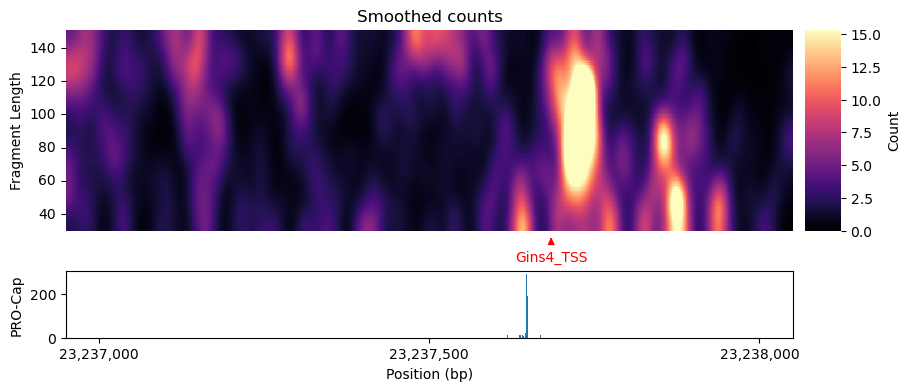

In [5]:
### Plot an example region
# Gins4 chr8:23226610-23237668 (-)

chrom = 'chr8'
start_bp = 23_237_000
end_bp = 23_238_000

#start_bp = 85_024_500
#end_bp = 85_027_500

markers = {
    23_237_668: 'Gins4_TSS'
}

footprint, raw_total_counts, procap = \
    get_footprint_and_procap(fragment_counts_gz=counts_gz, 
                                procap_bw=procap_bw,
                                avg_count_per_fragment_length=avg_by_len,
                                fragment_len_min=30, fragment_len_max=150,
                                chrom=chrom, window_start=start_bp, window_end=end_bp, footprint_sigma=10)

# Print footprint and procap shape
print(footprint.shape, raw_total_counts.shape, procap.shape)

plot_count_matrix(footprint, named_positions=markers, tracks = {'PRO-Cap': procap}, title='Smoothed counts', xtick_spacing=500)

Detected 9 blobs

Blob statistics:
  Mean size: 748.6 pixels
  Mean signal: 12.85
  Total signal: 110967.78

Top 5 blobs by total signal:
  1. Position: 23237712.0, Fragment length: 108.0, Size: 2640.0, Total signal: 49906.26
  2. Position: 23237701.0, Fragment length: 82.0, Size: 1990.0, Total signal: 34568.93
  3. Position: 23237841.0, Fragment length: 45.0, Size: 906.0, Total signal: 12593.69
  4. Position: 23237823.0, Fragment length: 83.0, Size: 594.0, Total signal: 7372.94
  5. Position: 23237628.0, Fragment length: 30.0, Size: 199.0, Total signal: 2254.54


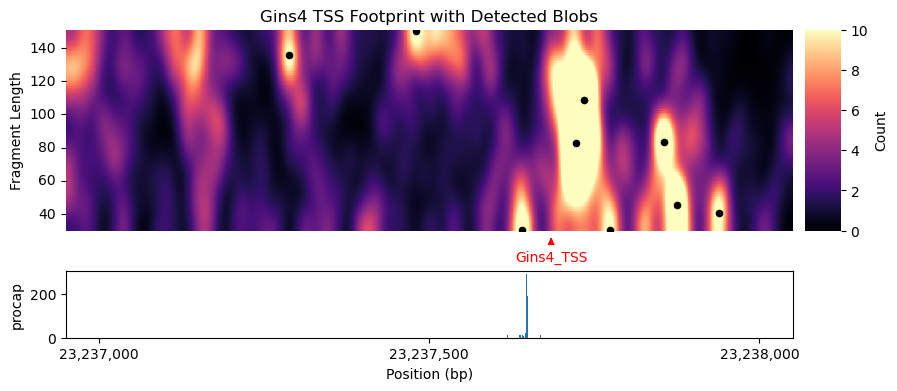

In [7]:
# Detect blobs in the footprint matrix

# Set parameters for blob detection
threshold = 10.0  # Minimum signal intensity to be considered part of a blob
sigma = 10.0       # Standard deviation for Gaussian smoothing
min_size = 5      # Minimum blob size in pixels

# Detect blobs in the footprint matrix
blobs = detect_blobs(
    footprint_matrix=footprint,
    threshold=threshold,
    min_size=min_size
)

# Print statistics about the detected blobs
print(f"Detected {len(blobs)} blobs")
if not blobs.empty:
    print("\nBlob statistics:")
    print(f"  Mean size: {blobs['size'].mean():.1f} pixels")
    print(f"  Mean signal: {blobs['mean_signal'].mean():.2f}")
    print(f"  Total signal: {blobs['total_signal'].sum():.2f}")
    
    # Sort blobs by total signal (descending) and print top 5
    top_blobs = blobs.sort_values('total_signal', ascending=False).head(5)
    print("\nTop 5 blobs by total signal:")
    for i, (_, blob) in enumerate(top_blobs.iterrows(), 1):
        print(f"  {i}. Position: {blob['position']}, Fragment length: {blob['fragment_length']}, "
              f"Size: {blob['size']}, Total signal: {blob['total_signal']:.2f}")

# Plot the footprint matrix with detected blobs
plot_count_matrix(
    footprint,
    named_positions=markers,
    tracks={'procap': procap},
    blobs=blobs,
    blob_marker='o',
    blob_color='black',
    blob_size=20,
    xtick_spacing=500,
    title="Gins4 TSS Footprint with Detected Blobs",
    vmax=10
)

[('chr8', 23230000, 23231999), ('chr8', 23232000, 23233999), ('chr8', 23234000, 23235999), ('chr8', 23236000, 23237999), ('chr8', 23238000, 23239999)]


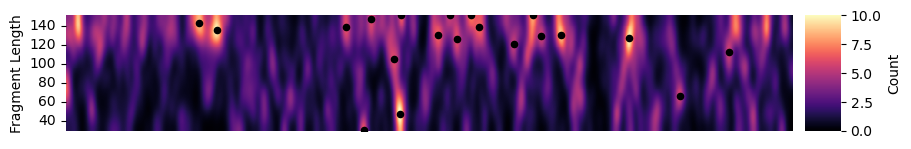

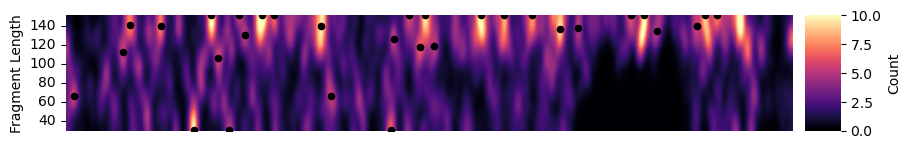

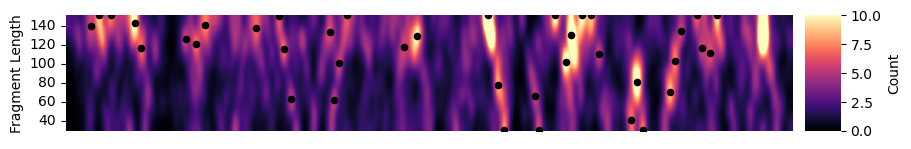

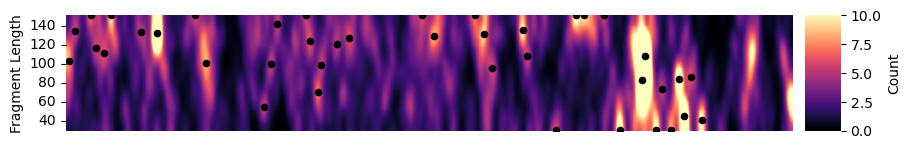

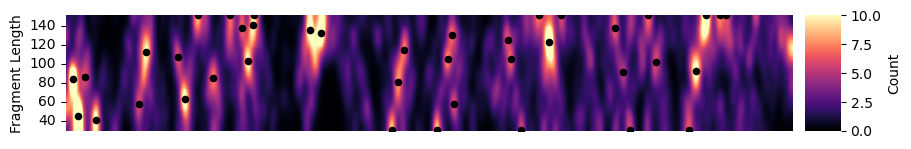

     fragment_length  position    size  max_signal  mean_signal  total_signal
0                 47  23230901  1237.0   10.483074     7.279838   9005.159707
1                135  23230297  1690.0    9.923708     6.998039  11826.686706
2                126  23231659  1706.0    9.868301     6.886924  11749.092902
3                130  23231433  1194.0    8.834746     6.690051   7987.921274
4                142  23230240  1249.0    8.577750     6.693981   8360.782436
..               ...       ...     ...         ...          ...           ...
150              101  23239746   331.0    5.883960     5.438609   1800.179442
151              150  23239435   146.0    5.782902     5.393324    787.425320
152               30  23239661   148.0    5.782209     5.392811    798.136099
153               30  23239303    80.0    5.657767     5.322740    425.819207
154               91  23239638    29.0    5.101507     5.050057    146.451661

[155 rows x 6 columns]


In [19]:
# Loop over a set of windows 

# Set parameters for blob detection
threshold = 5.0  # Minimum signal intensity to be considered part of a blob
sigma = 10.0       # Standard deviation for Gaussian smoothing
min_size = 5      # Minimum blob size in pixels



chrom = 'chr8'
start_bp = 23_230_000
end_bp = 23_240_000
window_size = 2000
pad = 200

# Make windows from start_bp to end_bp with a 500bp overlap
windows = []
for i in range(start_bp, end_bp, window_size):
    windows.append((chrom, i, i+window_size-1))

print(windows)

# Loop over windows
# Initialize blobs as an empty DataFrame before the loop (outside the loop)
blobs = pd.DataFrame()

for chrom, window_start, window_end in windows:
    footprint, _ = get_count_matrix(counts_gz, chrom, window_start-pad, window_end+pad, fragment_len_min=30, fragment_len_max=150, scale_factor_dict=avg_by_len, sigma=10)
    # Detect blobs in the footprint matrix
    window_blobs = detect_blobs(
        footprint_matrix=footprint,
        threshold=threshold, min_size=min_size
    )
    # Subset to blobs within (unpadded) window
    window_blobs = window_blobs[(window_blobs['position'] >= window_start) & (window_blobs['position'] <= window_end)]
    # Append window_blobs to blobs
    blobs = pd.concat([blobs, window_blobs], ignore_index=True)
    
    plot_count_matrix(footprint, blobs=blobs, blob_marker='o', blob_color='black', blob_size=20, 
                      xtick_spacing=500, figsize=(10, 1.5), vmax=10)

print(blobs)


In [18]:

footprint, _ = get_count_matrix(counts_gz, chrom, window_start-pad, window_end+pad, fragment_len_min=30, fragment_len_max=150, scale_factor_dict=avg_by_len, sigma=10)
print(footprint.shape  )
print(footprint)

(121, 2400)
pos              23237800  23237801  23237802  23237803  23237804  23237805  \
fragment_length                                                               
30               2.938593  2.950640  2.974037  3.009768  3.057946  3.118953   
31               2.979496  2.991290  3.014170  3.049126  3.096284  3.156035   
32               3.060833  3.072130  3.093993  3.127425  3.172574  3.229851   
33               3.180969  3.191537  3.211908  3.243103  3.285304  3.338949   
34               3.337828  3.347455  3.365899  3.394204  3.432595  3.481544   
...                   ...       ...       ...       ...       ...       ...   
146              1.941027  1.936059  1.926281  1.912000  1.893758  1.871900   
147              1.846231  1.842249  1.834413  1.822975  1.808402  1.790931   
148              1.773477  1.770247  1.763895  1.754629  1.742860  1.728740   
149              1.724177  1.721454  1.716104  1.708306  1.698431  1.686574   
150              1.699176  1.696711  1.6


Benchmarking window size: 1,000 bp
Processing 1250 windows...
Window size: 1,000 bp
Number of windows: 1250
Processing time: 14.58 seconds
Peak memory usage: 0.48 MB
Number of blobs detected: 147

Benchmarking window size: 5,000 bp
Processing 209 windows...
Window size: 5,000 bp
Number of windows: 209
Processing time: 8.33 seconds
Peak memory usage: 16.05 MB
Number of blobs detected: 147

Benchmarking window size: 10,000 bp
Processing 103 windows...
Window size: 10,000 bp
Number of windows: 103
Processing time: 7.59 seconds
Peak memory usage: 26.16 MB
Number of blobs detected: 147

Benchmarking window size: 25,000 bp
Processing 41 windows...
Window size: 25,000 bp
Number of windows: 41
Processing time: 7.80 seconds
Peak memory usage: 78.81 MB
Number of blobs detected: 147

Benchmarking window size: 50,000 bp
Processing 21 windows...
Window size: 50,000 bp
Number of windows: 21
Processing time: 8.01 seconds
Peak memory usage: 116.31 MB
Number of blobs detected: 147

Benchmarking window

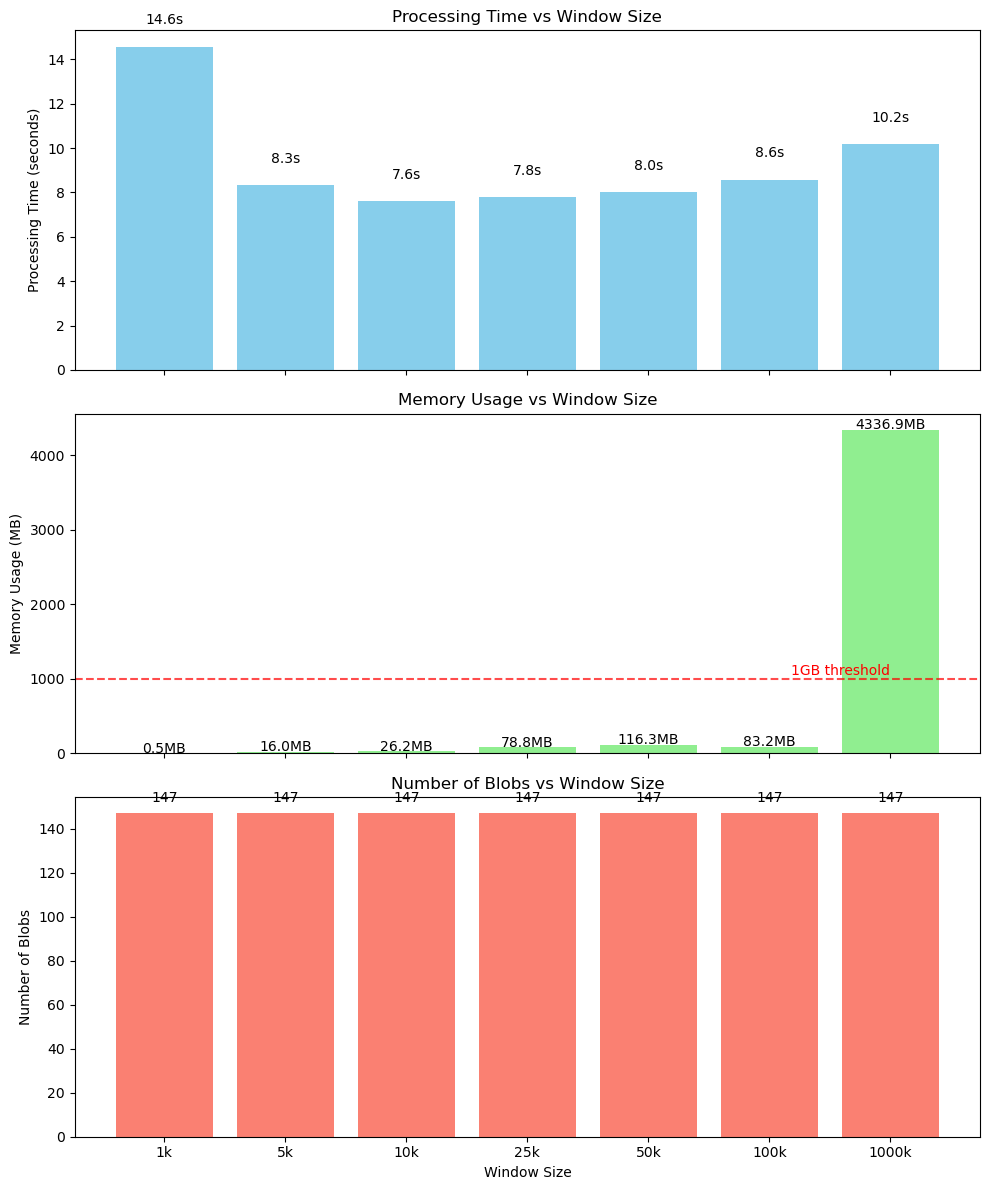


Optimal window size: 10,000.0 bp
Processing time: 7.59 seconds
Memory usage: 26.16 MB
Number of blobs: 147.0

This window size provides the best balance between processing speed and memory usage while staying under 1GB.


In [ ]:
# Benchmark different window sizes for blob detection across a large genomic region
# Using a fixed 200bp overlap between adjacent windows to ensure consistent detection of features at window boundaries
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from memory_profiler import memory_usage

def process_region_with_window(chrom, start, end, window_size, pad=200, threshold=5.0, sigma=1.0, min_size=5):
    """
    Process a genomic region using sliding windows of specified size.
    Windows have a fixed 200bp overlap between adjacent windows.
    
    Parameters
    ----------
    chrom : str
        Chromosome name
    start : int
        Start position of the region
    end : int
        End position of the region
    window_size : int
        Size of each window in base pairs
    pad : int
        Padding to add to each side of the window
    threshold : float
        Threshold for blob detection
    sigma : float
        Sigma for Gaussian smoothing in blob detection
    min_size : int
        Minimum blob size in pixels
        
    Returns
    -------
    tuple
        (all_blobs, processing_time, max_memory)
    """
    # Create windows
    windows = []
    for i in range(start, end, window_size):
        window_end = min(i + window_size-1, end)
        windows.append((chrom, i, window_end))
    
    # Initialize empty DataFrame for blobs
    all_blobs = pd.DataFrame()
    
    # Start timing
    start_time = time.time()
    
    # Define the function to be memory profiled
    def process_windows():
        nonlocal all_blobs
        for chrom, window_start, window_end in windows:
            # Get count matrix for this window
            try:
                footprint, _ = get_count_matrix(
                    counts_gz=counts_gz, 
                    chrom=chrom, 
                    window_start=window_start-pad, 
                    window_end=window_end+pad, 
                    fragment_len_min=30, 
                    fragment_len_max=150, 
                    scale_factor_dict=avg_by_len, 
                    sigma=10
                )
                
                # Detect blobs
                window_blobs = detect_blobs(
                    footprint_matrix=footprint,
                    threshold=threshold,
                    min_size=min_size
                )
                
                # Add window information to blobs
                if not window_blobs.empty:
                    window_blobs['window_start'] = window_start
                    window_blobs['window_end'] = window_end
                    
                    # Append to all_blobs
                    window_blobs = window_blobs[(window_blobs['position'] >= window_start) & (window_blobs['position'] <= window_end)]
                    all_blobs = pd.concat([all_blobs, window_blobs], ignore_index=True)
            except Exception as e:
                print(f"Error processing window {chrom}:{window_start}-{window_end}: {e}")
    
    # Run the function with memory profiling
    mem_usage = memory_usage(process_windows, interval=0.1, timeout=None, max_iterations=1)
    
    # Calculate processing time
    processing_time = time.time() - start_time
    
    # Calculate max memory usage (in MB)
    max_memory = max(mem_usage) - min(mem_usage)
    
    return all_blobs, processing_time, max_memory

# Define the region to process (chromosome 8 from 20,000,000 to 40,000,000)
chrom = 'chr8'
start_pos = 20_000_000
end_pos = 30_000_000

# Define window sizes to test (in base pairs)
window_sizes = [1_000, 5_000, 10_000, 25_000, 50_000, 100_000, 250_000]

# Initialize results dictionary
results = {
    'window_size': [],
    'num_windows': [],
    'processing_time': [],
    'memory_usage': [],
    'num_blobs': []
}

# Run benchmarks for each window size
for window_size in window_sizes:
    print(f"\nBenchmarking window size: {window_size:,} bp")
        
    # Calculate number of windows
    num_windows = (end_pos - start_pos) // window_size
    if (end_pos - start_pos) % window_size > 0:
        num_windows += 1
    
    print(f"Processing {num_windows} windows...")
    
    # Process the region
    blobs, proc_time, max_memory = process_region_with_window(
        chrom=chrom,
        start=start_pos,
        end=end_pos,
        window_size=window_size,
        pad=200
    )
    
    # Store results
    results['window_size'].append(window_size)
    results['num_windows'].append(num_windows)
    results['processing_time'].append(proc_time)
    results['memory_usage'].append(max_memory)
    results['num_blobs'].append(len(blobs))
    
    print(f"Window size: {window_size:,} bp")
    print(f"Number of windows: {num_windows}")
    print(f"Processing time: {proc_time:.2f} seconds")
    print(f"Peak memory usage: {max_memory:.2f} MB")
    print(f"Number of blobs detected: {len(blobs)}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display results table
print("\nBenchmark Results:")
print(results_df.to_string(index=False))

# Create visualization of results
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Format window sizes for display
window_sizes_labels = [f"{size/1000:.0f}k" for size in results['window_size']]

# Plot processing time
ax1.bar(window_sizes_labels, results['processing_time'], color='skyblue')
ax1.set_ylabel('Processing Time (seconds)')
ax1.set_title('Processing Time vs Window Size')
for i, v in enumerate(results['processing_time']):
    ax1.text(i, v + 1, f"{v:.1f}s", ha='center')

# Plot memory usage
ax2.bar(window_sizes_labels, results['memory_usage'], color='lightgreen')
ax2.set_ylabel('Memory Usage (MB)')
ax2.set_title('Memory Usage vs Window Size')
# Add a horizontal line at 1000 MB (1GB)
ax2.axhline(y=1000, color='red', linestyle='--', alpha=0.7)
ax2.text(len(window_sizes_labels)-1, 1050, '1GB threshold', color='red', ha='right')
for i, v in enumerate(results['memory_usage']):
    ax2.text(i, v + 10, f"{v:.1f}MB", ha='center')

# Plot number of blobs
ax3.bar(window_sizes_labels, results['num_blobs'], color='salmon')
ax3.set_ylabel('Number of Blobs')
ax3.set_xlabel('Window Size')
ax3.set_title('Number of Blobs vs Window Size')
for i, v in enumerate(results['num_blobs']):
    ax3.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

# Determine optimal window size
# The optimal window size balances processing speed and memory usage
# Larger windows (25-50kb) typically process faster as they require fewer total windows
# However, memory usage increases with window size, so we need to stay under 1GB
# With fixed 200bp overlap, larger windows also have less redundant processing compared to 50% overlap
# Find window sizes that keep memory usage under 1GB
valid_sizes = results_df[results_df['memory_usage'] < 1000]

if not valid_sizes.empty:
    # Find the window size with the best processing time among valid sizes
    optimal_idx = valid_sizes['processing_time'].idxmin()
    optimal_size = valid_sizes.iloc[optimal_idx]['window_size']
    optimal_time = valid_sizes.iloc[optimal_idx]['processing_time']
    optimal_memory = valid_sizes.iloc[optimal_idx]['memory_usage']
    
    print(f"\nOptimal window size: {optimal_size:,} bp")
    print(f"Processing time: {optimal_time:.2f} seconds")
    print(f"Memory usage: {optimal_memory:.2f} MB")
    print(f"Number of blobs: {valid_sizes.iloc[optimal_idx]['num_blobs']}")
    print("\nThis window size provides the best balance between processing speed and memory usage while staying under 1GB.")
else:
    print("\nAll tested window sizes exceed 1GB of memory usage.")
    print("Consider using smaller window sizes or optimizing the blob detection algorithm for better memory efficiency.")

In [19]:
# Get the count frequency distributions for each fragment length
print("Collecting count frequencies...")
freq_by_fraglen = counts_by_fraglen(counts_gz, chrom)
print(f"Found data for {len(freq_by_fraglen)} fragment lengths")

Found data for 198 fragment lengths


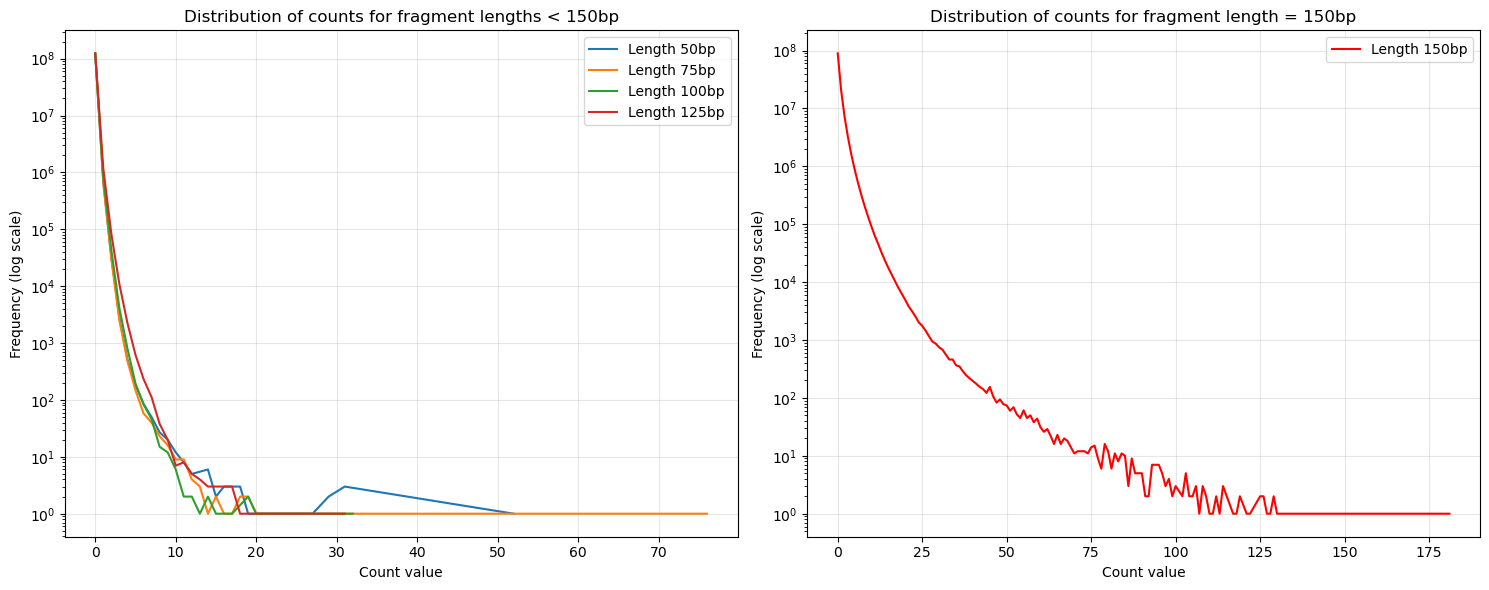

In [20]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Distribution of counts for fragment lengths < 150bp
ax1.set_title('Distribution of counts for fragment lengths < 150bp')
ax1.set_xlabel('Count value')
ax1.set_ylabel('Frequency (log scale)')

# Select a few representative fragment lengths to plot
fragment_lengths = [50, 75, 100, 125]
for frag_len in fragment_lengths:
    if frag_len in freq_by_fraglen:
        # Convert frequency table to arrays for plotting
        counts = list(freq_by_fraglen[frag_len].keys())
        frequencies = list(freq_by_fraglen[frag_len].values())
        
        # Sort by count value
        sorted_indices = np.argsort(counts)
        counts = [counts[i] for i in sorted_indices]
        frequencies = [frequencies[i] for i in sorted_indices]
        
        # Plot with log scale for frequency
        ax1.plot(counts, frequencies, label=f'Length {frag_len}bp')

ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution of counts for fragment length = 150bp
ax2.set_title('Distribution of counts for fragment length = 150bp')
ax2.set_xlabel('Count value')
ax2.set_ylabel('Frequency (log scale)')

if 150 in freq_by_fraglen:
    # Convert frequency table to arrays for plotting
    counts = list(freq_by_fraglen[150].keys())
    frequencies = list(freq_by_fraglen[150].values())
    
    # Sort by count value
    sorted_indices = np.argsort(counts)
    counts = [counts[i] for i in sorted_indices]
    frequencies = [frequencies[i] for i in sorted_indices]
    
    # Plot with log scale for frequency
    ax2.plot(counts, frequencies, label='Length 150bp', color='red')
    ax2.set_yscale('log')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [76]:
# Calculate and display statistics for each fragment length
print("\nStatistics for fragment length distributions:")
print("{:<10} {:<15} {:<15} {:<15} {:<15} {:<15} {:<15}".format(
    "Length", "Mean", "Variance", "Var/Mean", "Std Dev", "Log Mean", "Log Std Dev"))
print("-" * 100)

# Filter to only include specific fragment lengths
selected_lengths = [30, 50, 80]

for frag_len in selected_lengths:
    if frag_len in freq_by_fraglen:
        freq_table = freq_by_fraglen[frag_len]
        
        # Calculate mean and variance
        total_points = sum(freq_table.values())
        mean = sum(k * v for k, v in freq_table.items()) / total_points
        
        # Calculate variance: Var(X) = E[X²] - E[X]²
        mean_squared = sum(k**2 * v for k, v in freq_table.items()) / total_points
        variance = mean_squared - mean**2
        std_dev = np.sqrt(variance)
        
        # Calculate variance-to-mean ratio (dispersion parameter)
        var_to_mean = variance / mean if mean > 0 else 0
        
        # Calculate log-transformed statistics (add 1 to avoid log(0))
        log_values = [np.log1p(k) for k in freq_table.keys() for _ in range(freq_table[k])]
        log_mean = np.mean(log_values) if log_values else 0
        log_std = np.std(log_values) if len(log_values) > 1 else 0
        
        print("{:<10} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f}".format(
            frag_len, mean, variance, var_to_mean, std_dev, log_mean, log_std))
    else:
        print("{:<10} {:<15} {:<15} {:<15} {:<15} {:<15} {:<15}".format(
            frag_len, "N/A", "N/A", "N/A", "N/A", "N/A", "N/A"))


Statistics for fragment length distributions:
Length     Mean            Variance        Var/Mean        Std Dev         Log Mean        Log Std Dev    
----------------------------------------------------------------------------------------------------
30         0.0046          0.0056          1.2208          0.0748          0.0031          0.0477         
50         0.0062          0.0071          1.1410          0.0840          0.0042          0.0551         
80         0.0053          0.0059          1.1169          0.0766          0.0036          0.0507         


Aggregating count data for fragments ≤ 80bp...
Total positions analyzed: 7240776028


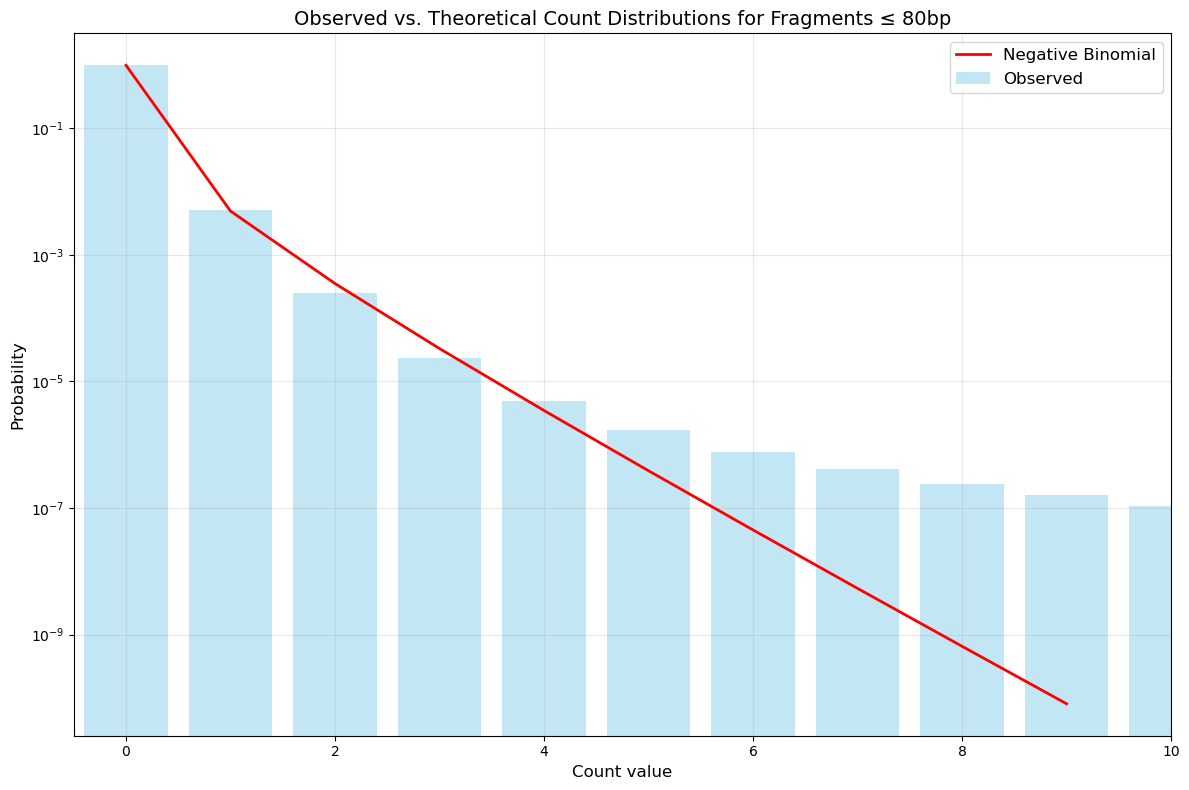

In [83]:
# Analyze count distributions for fragments ≤ 80bp
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Combine count frequency data for all fragments with lengths ≤ 80bp
print("Aggregating count data for fragments ≤ 80bp...")
combined_freq = {}
total_positions = 0

for frag_len, freq_table in freq_by_fraglen.items():
    if frag_len <= 80:
        # Add counts from this fragment length to the combined frequency table
        for count, freq in freq_table.items():
            if count in combined_freq:
                combined_freq[count] += freq
            else:
                combined_freq[count] = freq
            total_positions += freq

print(f"Total positions analyzed: {total_positions}")

# 2. Estimate Negative Binomial parameters using method of moments
# Calculate sample mean and variance
counts = []
freqs = []
for count, freq in combined_freq.items():
    counts.append(count)
    freqs.append(freq)

counts = np.array(counts)
freqs = np.array(freqs)

# Calculate mean and variance using the frequency table
mean = np.sum(counts * freqs) / np.sum(freqs)
variance = np.sum((counts - mean)**2 * freqs) / np.sum(freqs)

# Estimate dispersion parameter
if variance > mean:
    dispersion = mean**2 / (variance - mean)
else:
    dispersion = 1000.0  # Not overdispersed, use large value (approaching Poisson)

# Calculate variance-to-mean ratio
var_mean_ratio = variance / mean

# 3. Generate theoretical distributions
max_count = max(counts)
x_range = np.arange(0, max_count + 1)
#x_range = np.arange(0, 6)

# Negative Binomial PMF
# Using scipy's parameterization: n=dispersion, p=dispersion/(dispersion+mean)
p_nb = dispersion / (dispersion + mean)
nb_pmf = stats.nbinom.pmf(x_range, dispersion, p_nb)

# Poisson PMF
poisson_pmf = stats.poisson.pmf(x_range, mean)

# 4. Normalize observed data to create a probability distribution
observed_pmf = np.zeros_like(x_range, dtype=float)
for i, count in enumerate(counts):
    observed_pmf[count] = freqs[i] / np.sum(freqs)

# 5. Create the plot
plt.figure(figsize=(12, 8))

# Plot observed data as bars
plt.bar(x_range, observed_pmf, alpha=0.5, label='Observed', color='skyblue', width=0.8)

# Plot theoretical distributions as lines
plt.plot(x_range[0:10], nb_pmf[0:10], 'r-', linewidth=2, label='Negative Binomial')
#plt.plot(x_range[0:10], poisson_pmf[0:10], 'g--', linewidth=2, label='Poisson')

# Set log scale for y-axis
plt.yscale('log')

# Add labels and title
plt.xlabel('Count value', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Observed vs. Theoretical Count Distributions for Fragments ≤ 80bp', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Limit x-axis to make the plot more readable
plt.xlim(-0.5, min(10, max_count))

plt.tight_layout()
plt.show()


In [ ]:
# 6. Print estimated parameters
print("\nEstimated Distribution Parameters:")
print(f"Mean (μ): {mean:.4f}")
print(f"Variance (σ²): {variance:.4f}")
print(f"Dispersion parameter (α): {dispersion:.4f}")
print(f"Variance-to-mean ratio (σ²/μ): {var_mean_ratio:.4f}")

# 7. Assess goodness of fit
# Calculate sum of squared errors
sse_nb = np.sum((observed_pmf - nb_pmf)**2)
sse_poisson = np.sum((observed_pmf - poisson_pmf)**2)

print("\nGoodness of Fit:")
print(f"Sum of squared errors (Negative Binomial): {sse_nb:.6f}")
print(f"Sum of squared errors (Poisson): {sse_poisson:.6f}")

# Perform chi-square goodness-of-fit test if appropriate
# We need to bin the data to have expected frequencies > 5
expected_nb = nb_pmf * np.sum(freqs)
expected_poisson = poisson_pmf * np.sum(freqs)

# Bin data where expected frequencies are too small
min_expected = 5
observed_binned = []
expected_nb_binned = []
expected_poisson_binned = []
current_bin_obs = 0
current_bin_exp_nb = 0
current_bin_exp_poisson = 0

for i in range(len(x_range)):
    obs = observed_pmf[i] * np.sum(freqs)
    exp_nb = expected_nb[i]
    exp_poisson = expected_poisson[i]
    
    current_bin_obs += obs
    current_bin_exp_nb += exp_nb
    current_bin_exp_poisson += exp_poisson
    
    if current_bin_exp_nb >= min_expected and current_bin_exp_poisson >= min_expected:
        observed_binned.append(current_bin_obs)
        expected_nb_binned.append(current_bin_exp_nb)
        expected_poisson_binned.append(current_bin_exp_poisson)
        current_bin_obs = 0
        current_bin_exp_nb = 0
        current_bin_exp_poisson = 0

# Add the last bin if not empty
if current_bin_obs > 0:
    observed_binned.append(current_bin_obs)
    expected_nb_binned.append(current_bin_exp_nb)
    expected_poisson_binned.append(current_bin_exp_poisson)

# Perform chi-square test if we have enough bins
if len(observed_binned) > 3:  # Need at least 3 bins for the test
    chi2_nb, p_nb = stats.chisquare(observed_binned, expected_nb_binned)
    chi2_poisson, p_poisson = stats.chisquare(observed_binned, expected_poisson_binned)
    
    print(f"\nChi-square test (Negative Binomial): χ² = {chi2_nb:.4f}, p-value = {p_nb:.6f}")
    print(f"Chi-square test (Poisson): χ² = {chi2_poisson:.4f}, p-value = {p_poisson:.6f}")
    
    if p_nb > p_poisson:
        print("\nConclusion: The Negative Binomial distribution provides a better fit to the data.")
        if var_mean_ratio > 1.5:
            print("The data shows significant overdispersion (variance > mean), which is better modeled by the Negative Binomial distribution.")
    else:
        print("\nConclusion: The Poisson distribution provides a better fit to the data.")
        if var_mean_ratio < 1.5:
            print("The data does not show significant overdispersion, which is consistent with the Poisson distribution.")
else:
    print("\nInsufficient data for chi-square test.")
    if sse_nb < sse_poisson:
        print("Based on sum of squared errors, the Negative Binomial distribution provides a better fit.")
    else:
        print("Based on sum of squared errors, the Poisson distribution provides a better fit.")



Estimated Distribution Parameters:
Mean (μ): 0.0057
Variance (σ²): 0.0067
Dispersion parameter (α): 0.0358
Variance-to-mean ratio (σ²/μ): 1.1604

Goodness of Fit:
Sum of squared errors (Negative Binomial): 0.000000
Sum of squared errors (Poisson): 0.000001

Chi-square test (Negative Binomial): χ² = 332586.4858, p-value = 0.000000
Chi-square test (Poisson): χ² = 12253923353.4240, p-value = 0.000000

Conclusion: The Poisson distribution provides a better fit to the data.
The data does not show significant overdispersion, which is consistent with the Poisson distribution.


In [6]:
# Test get_valid_windows

windows = get_valid_windows(
    counts_gz, 
    chromosomes=[('chr8', 23_237_000, 23_239_000), ('chr8', 23_300_000, 23_302_000)], 
    window_overlap_bp=0, 
    window_size=1024, 
    maxgap=1000,
    max_windows=10
)

print(windows)

[('chr8', 23237001, 23238024), ('chr8', 23300003, 23301026)]


In [7]:
# Train a model on a small dataset

# Initialize W&B run
wandb.init(project="footprint-to-procap", name="run3")

# Create the WandbLogger
wandb_logger = WandbLogger(
    project="footprint-to-procap",
    log_model=False,      # we’ll use our own checkpoint callback
)

# Create a checkpoint callback to save the best val_loss
checkpoint_cb = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="footprint-{epoch:02d}-{val_loss:.4f}",
    auto_insert_metric_name=False,
)

counts_gz = '../data/mesc_microC_3hrDMSO_chr8.counts.tsv.gz'
procap_bw = '../data/GSM2170014_Pro_mESC.ucsc_mm10.bw'

# Create training and validation windows. Exclude test region
regions = get_valid_windows(counts_gz, chromosomes=[('chr8', 0, 23_000_000), ('chr8', 24_000_000, 1e9)], 
    window_size=1024, maxgap=500)
print(f"Number of windows: {len(regions)}")
np.random.shuffle(regions)
train_regions, val_regions = regions[:int(len(regions)*0.8)], regions[int(len(regions)*0.8):]
print(f"Number of training windows: {len(train_regions)}")
print(f"Number of validation windows: {len(val_regions)}")

data_accessor_fn = partial(get_footprint_and_procap, counts_gz, procap_bw, avg_by_len)

dm = FootprintDataModule(train_regions=train_regions, val_regions=val_regions, test_regions=[], accessor_fn=data_accessor_fn, batch_size=64, num_workers=4)
model = UNetLightning(in_channels=1, base_filters=32)
trainer = Trainer(accelerator="mps", max_epochs=2, gradient_clip_val=1.0, logger=wandb_logger, callbacks=[checkpoint_cb])
trainer.fit(model, dm)

wandb.save(checkpoint_cb.best_model_path)


wandb: Currently logged in as: martin-aryee (aryeelab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/martin/miniforge3/envs/tf_footprinting/lib/python3.12/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.

   | Name         | Type            | Params | Mode 
----------------------------------------------------------
0  | enc1         | Sequential      | 9.7 K  | train
1  | pool1        | MaxPool2d       | 0      | train
2  | enc2         | Sequential      | 55.7 K | train
3  | pool2        | MaxPool2d       | 0      | train
4  | enc3         | Sequential      | 221 K  | train
5  | pool3        | MaxPool2d       | 0      | train
6  | enc4         | Sequential      | 886 K  | train
7  | pool4        | MaxPool2d       | 0      | train
8  | bottleneck   | Sequential      | 3.5 M 

Number of windows: 116598
Number of training windows: 93278
Number of validation windows: 23320
Epoch 1: 100%|██████████| 1458/1458 [3:49:28<00:00,  0.11it/s, v_num=kg6u, val_mu_min=2.710, val_mu_max=51.70, val_probs_min=0.0224, val_probs_max=0.398, val_loss=0.0457] 

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 1458/1458 [3:49:28<00:00,  0.11it/s, v_num=kg6u, val_mu_min=2.710, val_mu_max=51.70, val_probs_min=0.0224, val_probs_max=0.398, val_loss=0.0457]


['/Users/martin/projects/footprint-tools/code/wandb/run-20250513_130038-kn0kkg6u/files/footprint-to-procap/kn0kkg6u/checkpoints/footprint-01-0.0457.ckpt']

In [10]:
# Predict test regions

model = UNetLightning.load_from_checkpoint("/Users/martin/projects/footprint-tools/code/wandb/run-20250513_130038-kn0kkg6u/files/footprint-to-procap/kn0kkg6u/checkpoints/footprint-01-0.0457.ckpt")
trainer = Trainer(accelerator="mps")

# Create a set of test regions
test_regions = [
    ("chr8", 23_237_000, 23_238_023), # Gins4
    ("chr8", 23_208_000, 23_209_023), # Gpat4
]

data_accessor_fn = partial(get_footprint_and_procap, counts_gz, procap_bw, avg_by_len)

# turn off shuffling and set batch_size=1
dm_test = FootprintDataModule(train_regions=[], val_regions=[], test_regions=test_regions, 
                              accessor_fn=data_accessor_fn,
                              batch_size=1, num_workers=1)

dm_test.setup()
test_loader = dm_test.test_dataloader()

# run predictions
preds = trainer.predict(model, test_loader)

trues, mus, xs = [], [], []
for batch, pred in zip(test_loader, preds):
    x, y_true = batch            # y_true: (1, 1024)
    mu  = pred["mu"]             # mu: (1, 1024)
    xs.append(x.squeeze().cpu().numpy())
    trues.append(y_true.squeeze().cpu().numpy())
    mus.append(mu.squeeze().cpu().numpy())


Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/martin/miniforge3/envs/tf_footprinting/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/Users/martin/miniforge3/envs/tf_footprinting/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not

Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  2.30it/s]


x shape: (128, 1024)
mu shape: (1024,)
true shape: (1024,)


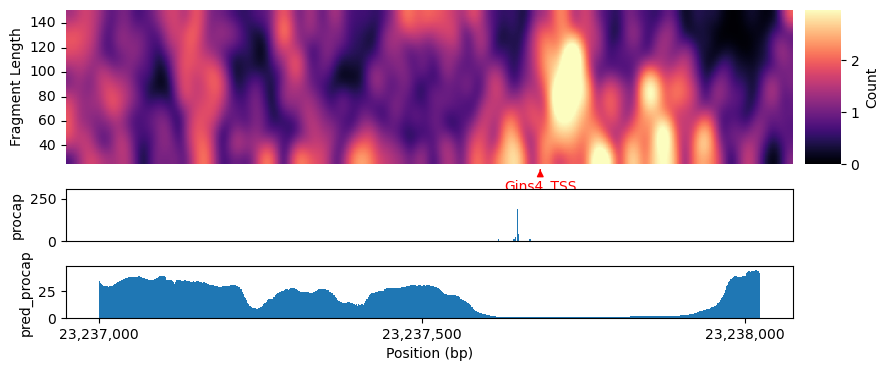

In [11]:
# View predictions

i = 0

_, start_bp, _ = test_regions[i]
x = xs[i]  # (128, 1024)
mu = mus[i]  # (1024,)
true = trues[i]  # (1024,)

print("x shape:", x.squeeze().shape)
print("mu shape:", mu.shape)
print("true shape:", true.shape)

# define your fragment‐length index and genomic‐position columns
fragment_len_min = 25
fragment_len_max = 150
frag_lens = np.arange(fragment_len_min, fragment_len_max + 1)       
positions = np.arange(1024) + start_bp    

# build the DataFrame
df_fp = pd.DataFrame(x[1:127, :], index=frag_lens, columns=positions)

# similarly make a Series for the true procap
ser_procap = pd.Series(true, index=positions)
ser_pred_procap = pd.Series(mu, index=positions)

# Gins4 chr8:23226610-23237668 (-)
markers = {
    23_237_668: 'Gins4_TSS',
    #23_237_650: 'PRO-Cap peak',
}


# now call the plotter
plot_count_matrix(
    df_fp,
    named_positions=markers,
    tracks={'procap': ser_procap, 'pred_procap': ser_pred_procap},
    xtick_spacing=500
)

In [ ]:
# Experiment with different threshold values
thresholds = [10.0, 15.0, 20.0]
blob_results = {}

for threshold in thresholds:
    # Detect blobs with current threshold
    blobs = detect_blobs(
        footprint_matrix=df_fp,
        threshold=threshold,
        sigma=sigma,
        min_size=min_size
    )
    
    # Store results
    blob_results[threshold] = {
        'count': len(blobs),
        'blobs': blobs
    }
    
    # Print statistics
    print(f"Threshold: {threshold}")
    print(f"  Detected {len(blobs)} blobs")
    if not blobs.empty:
        print(f"  Mean size: {blobs['size'].mean():.1f} pixels")
        print(f"  Mean signal: {blobs['mean_signal'].mean():.2f}")
    print()
    
    # Plot the footprint matrix with detected blobs
    plot_count_matrix(
        df_fp,
        named_positions=markers,
        tracks={'procap': ser_procap},
        blobs=blobs,
        blob_marker='o',
        blob_color='white',
        blob_size=20,
        xtick_spacing=500,
        title=f"Threshold: {threshold}, Detected {len(blobs)} blobs"
    )

In [ ]:
# Experiment with different sigma values
sigmas = [0.5, 1.0, 2.0]
threshold = 15.0  # Use a fixed threshold

for sigma in sigmas:
    # Detect blobs with current sigma
    blobs = detect_blobs(
        footprint_matrix=df_fp,
        threshold=threshold,
        sigma=sigma,
        min_size=min_size
    )
    
    # Print statistics
    print(f"Sigma: {sigma}")
    print(f"  Detected {len(blobs)} blobs")
    if not blobs.empty:
        print(f"  Mean size: {blobs['size'].mean():.1f} pixels")
        print(f"  Mean signal: {blobs['mean_signal'].mean():.2f}")
    print()
    
    # Plot the footprint matrix with detected blobs
    plot_count_matrix(
        df_fp,
        named_positions=markers,
        tracks={'procap': ser_procap},
        blobs=blobs,
        blob_marker='o',
        blob_color='white',
        blob_size=20,
        xtick_spacing=500,
        title=f"Sigma: {sigma}, Detected {len(blobs)} blobs"
    )